<a href="https://colab.research.google.com/github/ivyg15/2024-Summer-Research/blob/main/2024Paper_Stag_Hunt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
from random import random
import math

In [ ]:
# Example state and action dimensions
state_dim = 2
action_dim = 2
hidden_dim = 2

# rewards
r = np.array([[5, 0], [4, 2]])

tau1 = 0.001 # risk aversion
tau2 = 0.001
epsilon = 0.001 # bounded rationality
lr = 0.01 # learning rate
lr2 = 0.00001

In [ ]:
class PolicyNetwork(nn.Module):
  def __init__(self, state_dim, action_dim, hidden_dim):
    super(PolicyNetwork, self).__init__()
    self.layer1 = nn.Linear(state_dim, hidden_dim)
    self.layer2 = nn.Linear(hidden_dim, action_dim)
    self.softmax = nn.Softmax(dim=-1)

  def forward(self, state):
    x = self.layer1(state)
    x = self.layer2(x)
    x = self.softmax(x)
    return x

  def getProbs(self, state):
    actionProbs = self.forward(state)
    return actionProbs

In [ ]:
def step(policy, grads):
  #print(grads)
  for name, parameter in policy.named_parameters():
    if not np.isnan(grads[name]).any():
      parameter.data = torch.add(parameter, torch.Tensor(grads[name]), alpha=lr*-1)

In [ ]:
def regularize(probs):
  r = 0
  for i in range(2):
    r += probs.squeeze()[i] * torch.log(probs.squeeze()[i])
  return r

def KL(p, q):
  r = 0
  for i in range(2):
    r += p.squeeze()[i] * torch.log(p.squeeze()[i] / q.squeeze()[i])
  return r

In [ ]:
def updatePolicy(player, playerProbs, player2Probs, tau):
  # maximum of part of expression that depends on p
  adversaryProbs = player2Probs.clone().detach().numpy()

  if adversaryProbs[0] == 0:
    adversaryProbs[0] = 1e-7
  elif adversaryProbs[0] == 1:
    adversaryProbs[0] = 1 - 1e-7

 # print(playerProbs)

  alpha = player2Probs[0].detach().numpy()
  #print(alpha)
  for i in range(500):
    lossGradient = np.dot((playerProbs).detach().numpy(), np.matmul(r, [1,-1])) + (adversaryProbs[0]-alpha)/(adversaryProbs[0]*adversaryProbs[1]*tau)
    adversaryProbs[0] -= lr2 * lossGradient
    if (adversaryProbs[0] <= 0):
      adversaryProbs[0] = 0
      adversaryProbs[1] = 1
      break
    if (adversaryProbs[0] >= 1):
      adversaryProbs[0] = 1
      adversaryProbs[1] = 0
      break
    adversaryProbs[1] = 1 - adversaryProbs[0]


  # print(player2Probs)
  # print("\n")
  loss = -1 * torch.matmul(playerProbs, torch.matmul(torch.Tensor(r), torch.Tensor(adversaryProbs))) - KL(player2Probs, adversaryProbs)/tau + regularize(playerProbs)*epsilon
  # print("loss ", loss)
  loss.backward(retain_graph = True)
  grads = {}
  for name, parameter in player.named_parameters():
    grads[name] = parameter.grad.numpy()
  # print(grads)
  step(player, grads)
  # for p in player.parameters():
  #   print(p)


In [ ]:
episodes = 100

player1 = PolicyNetwork(state_dim, action_dim, hidden_dim)
player2 = PolicyNetwork(state_dim, action_dim, hidden_dim)

state = torch.Tensor([1,1]) # bc states are really just the policies

stagFrequency1 = [] # frequency of stag per episode of agent 1
stagFrequency2 = [] # frequency of stag per episode of agent 2

for i in range(episodes):
  player1probs = player1.getProbs(state)
  player2probs = player2.getProbs(state)

  # print(player1probs)
  # print(player2probs)
  # print("\n")

  updatePolicy(player2, player2probs, player1probs, tau2)
  updatePolicy(player1, player1probs, player2probs, tau1)



  stagFrequency1.append(np.squeeze(player1probs.detach().numpy())[0])
  stagFrequency2.append(np.squeeze(player2probs.detach().numpy())[0])


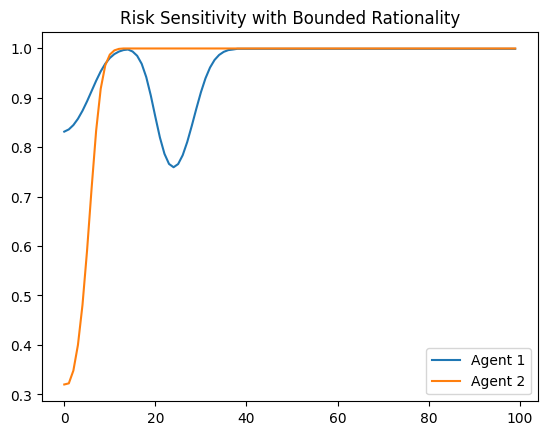

In [ ]:
import matplotlib.pyplot as plt

plt.plot(stagFrequency1, label="Agent 1")
plt.plot(stagFrequency2, label="Agent 2")
plt.legend()
plt.title("Risk Sensitivity with Bounded Rationality")
plt.show()